In [1]:
from collections import namedtuple

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from vorpy.symplectic_integration.nonseparable_hamiltonian import integrate, heuristic_estimate_for_omega
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from tqdm import tqdm

from cgc.graph import ComputationalGraph, derivative
from cgc.optimizers import TwoStepsNGDptimizerForKF
from cgc.utils import KernelParameter as KP

from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")

pd.set_option("display.precision", 17)

np.int = int


# Experiment Configurations

In [7]:
N_TRAJICTORIES_TRAIN = 5
N_TRAJICTORIES_TEST = 50

N = 400
T_MAX = 80
OBSERVATIONS_END = 200
SPARSITY_FACTOR = 0.5
KFLOW_LEARNING = False
USE_SYMPLECTIC_INTEGERATION = False

H_KERNEL = "separable-polynomial"
H_KERNEL_PARAMS = {"constant": KP(1, learnable=False), "exponent": KP(3.0, learnable=False)}
H_KERNEL_NUGGET = 0.001

# The following is applied to all components of p in the system
P_KERNEL = "gaussian"
P_KERNEL_PARAMS = {"scale": KP(1.0, learnable=True)}
P_KERNEL_NUGGET = 1e-5

# The following is applied to all components of q in the system
Q_KERNEL = "gaussian"
Q_KERNEL_PARAMS = {"scale": KP(1.0, learnable=True)}
Q_KERNEL_NUGGET = 1e-5

TRUE_COEFS = jnp.asarray([0, 0, 0, 0.5, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0.5, 0, 0.5, 0, 1, 0, -(1/3)])

TRAIN_BANDS = [(0.02, 0.08), (0.11, 0.13)] 
TEST_BANDS = [(0.09, 0.11), (0.13, 0.15)]

In [8]:
def get_pq_from(graph: ComputationalGraph, Z):
    _, size = Z.shape
    dims = (size - 2) // 2

    p_fns = [graph._unknown_functions[f"p{index + 1 if dims > 1 else ''}"] for index in range(dims)]
    q_fns = [graph._unknown_functions[f"q{index + 1 if dims > 1 else ''}"] for index in range(dims)]   

    def pq_fn(t):
        ps = [p_fn._f(t, p_fn.parameter(Z), p_fn.observation(Z)) for p_fn in p_fns]
        qs = [q_fn._f(t, q_fn.parameter(Z), q_fn.observation(Z)) for q_fn in q_fns]

        return jnp.hstack(ps + qs)

    return pq_fn

In [9]:
from cgc.kernels.factory import KernelsFactory

def __reduce_mask(nd_mask):
        reduced_mask = nd_mask
        if nd_mask.ndim > 1:
            reduced_mask = np.multiply.reduce(nd_mask, axis=1).astype(bool)
        return reduced_mask

def _adjust_y_train_shape(matrix, y_train):
    _, matrix_trainling_dim_size = matrix.shape
    observation_leading_dim_size, *_ = y_train.shape

    if matrix_trainling_dim_size != observation_leading_dim_size:
        y_train = jnp.reshape(y_train, (matrix_trainling_dim_size, ), order='F')

    return y_train

def _adjust_sims_shape(matrix, sims):
    _, matrix_trainling_dim_size = matrix.shape
    *_, sims_trailing_dim_size = sims.shape

    if matrix_trainling_dim_size != sims_trailing_dim_size:
        sims = jnp.reshape(sims, (matrix_trainling_dim_size, ), order='F')

    return sims


def one_step_hamiltonian(Z, observations_end, num_trajectories=1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET, linear_functional=jax.jacobian)

    _, pq_size = Z.shape
    ndims = (pq_size - 6) // 2
    p_start, p_end = 5, ndims + 5
    q_start, q_end = ndims + 5, 2 * ndims + 5

    T_train = Z[:observations_end * num_trajectories, 0:5]
    P_train = Z[:observations_end * num_trajectories, p_start:p_end]
    Q_train = Z[:observations_end * num_trajectories, q_start:q_end]

    def p(t):
        sims = p_kernel(t, T_train)
        matrix = p_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, P_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    def q(t):
        sims = q_kernel(t, T_train)
        matrix = q_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, Q_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    p_dot = jax.jacobian(p)
    q_dot = jax.jacobian(q)

    PQ_train = jnp.concatenate((P_train, Q_train), axis=1)
    QP_DOT_train = jnp.concatenate((
            jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_train))[:, :, 0],
            jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_train))[:, :, 0]
        ),
        axis=1
    )

    H_matrix = H_kernel.matrix(PQ_train)
    H_y_train = _adjust_y_train_shape(H_matrix, QP_DOT_train)
    inv = jnp.linalg.solve(H_matrix, H_y_train)

    def H(pq):
        sims = H_kernel(pq, PQ_train)

        sims = _adjust_sims_shape(H_matrix, sims)

        return jnp.squeeze(sims @ inv)
    
    return H


def two_steps_pqH(X, M, observations_end, use_T_in_second_step=False, num_trajectories=1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET, linear_functional=jax.jacobian)


    _, pq_size = X.shape
    ndims = (pq_size - 6) // 2
    p_start, p_end = 5, ndims + 5
    q_start, q_end = ndims + 5, 2 * ndims + 5
    true_observations_mask = __reduce_mask(M[:observations_end * num_trajectories, 5:pq_size - 1])

    T_ghost = X[:observations_end * num_trajectories, 0:5]
    T_train = X[:observations_end * num_trajectories, 0:5][true_observations_mask]
    P_train = X[:observations_end * num_trajectories, p_start:p_end][true_observations_mask]
    Q_train = X[:observations_end * num_trajectories, q_start:q_end][true_observations_mask]

    def p(t):
        sims = p_kernel(t, T_train)
        matrix = p_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, P_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    def q(t):
        sims = q_kernel(t, T_train)
        matrix = q_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, Q_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    p_dot = jax.jacobian(p)
    q_dot = jax.jacobian(q)

    if use_T_in_second_step:
        PQ_train = jnp.concatenate((jax.jit(jax.vmap(p))(T_ghost), jax.jit(jax.vmap(q))(T_ghost)), axis=1)
        QP_DOT_train = jnp.concatenate((
                jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_ghost))[:, :, 0], 
                jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_ghost))[:, :, 0])
            , axis=1)
    else:
        PQ_train = jnp.concatenate((P_train, Q_train), axis=1)
        QP_DOT_train = jnp.concatenate((
                jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_train))[:, :, 0],
                jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_train))[:, :, 0]
            )
        )


    H_matrix = H_kernel.matrix(PQ_train)
    H_y_train = _adjust_y_train_shape(H_matrix, QP_DOT_train)
    inv = jnp.linalg.solve(H_matrix, H_y_train)

    def H(pq):
        sims = H_kernel(pq, PQ_train)

        sims = _adjust_sims_shape(H_matrix, sims)

        return jnp.squeeze(sims @ inv)
    
    return p, q, H


def integerate_H_est(H_est, init_point, time, dims=1):
    
    H_grad = jax.jit(jax.grad(H_est))
    
    def kernel_ode(pq, t):
        grad_val = H_grad(pq)
        dpH = grad_val[0: dims]
        dqH = grad_val[dims: 2 * dims]

        return np.concatenate([-dqH, dpH])
    
    pq = odeint(kernel_ode, init_point, time)

    return pq

def initialize_X_for_one_step(X, M, p_fn, q_fn, H_fn, dims=1):
    
    _, pq_size = X.shape
    X_initialized = X.copy()
    extra_steps = N - OBSERVATIONS_END

    T = X[:, 0]
    true_observations_mask = __reduce_mask(M[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 5:pq_size - 1])
    
    for i in range(N_TRAJICTORIES_TRAIN):

        init_point = X[OBSERVATIONS_END * (i + 1)  - 1, 5:pq_size - 1]
        
        extrapolation_time_start = OBSERVATIONS_END * N_TRAJICTORIES_TRAIN
        extrapolation_time = np.concatenate((
            np.reshape(T[OBSERVATIONS_END * (i + 1) - 1], (1,)), 
            T[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1)]
        ), axis=0)

        pq_2s = integerate_H_est(H_fn, init_point, extrapolation_time, dims=dims)

        X_initialized[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1), 5:pq_size - 1] = pq_2s[1:, :]

    pq_interpolated = jnp.concatenate((
            jax.jit(jax.vmap(p_fn))(X[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 0:5]),
            jax.jit(jax.vmap(q_fn))(X[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 0:5])
        ),
        axis=1
    )

    X_initialized[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 5:pq_size - 1][~true_observations_mask] = pq_interpolated[~true_observations_mask, :]
    H_init = jax.jit(jax.vmap(H_fn))(X_initialized[:, 5:pq_size - 1])
    X_initialized[:, pq_size - 1] = H_init

    return X_initialized


def initalize_one_step_loss_multipliers(graph, X_init, M):
    _, separate_losses = graph._loss(X_init, X_init, M, return_separate=True)
    rkhs_order_magnitude = np.floor(np.log10(separate_losses.get("rkhs_norm")))
    unk_funcs_order_magnitude = np.floor(np.log10(separate_losses.get("unknown_funcs_loss")))
    constraints_order_magnitude = np.floor(np.log10(separate_losses.get("constraints_loss")))
    data_compliance_order_magnitude = np.floor(np.log10(separate_losses.get("data_compliance_loss")))

    unknown_functions_loss_multiplier = 10 ** (rkhs_order_magnitude - unk_funcs_order_magnitude)
    constraint_loss_multiplier = 10 ** (rkhs_order_magnitude - constraints_order_magnitude)
    data_compliance_loss_multiplier = 10 ** (rkhs_order_magnitude - data_compliance_order_magnitude)

    return unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier

In [10]:
from sklearn.preprocessing import PolynomialFeatures
import re

def get_seprable_H_coef(Z, observations_end, num_trajectories = 1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET)

    _, pq_size = Z.shape
    ndims = (pq_size - 6) // 2
    p_start, p_end = 5, ndims + 5
    q_start, q_end = ndims + 5, 2 * ndims + 5

    H_estimated = Z[:observations_end * num_trajectories, -1]
    T_train = Z[:observations_end * num_trajectories, 0:3]
    P_train = Z[:observations_end * num_trajectories, p_start:p_end]
    Q_train = Z[:observations_end * num_trajectories, q_start:q_end]
    PQ_train = jnp.concatenate((P_train, Q_train), axis=1)


    H_k = H_kernel.matrix(PQ_train)


    poly_features = PolynomialFeatures(degree=3)
    mapped_features = np.concatenate((
        poly_features.fit_transform(P_train),
        poly_features.fit_transform(Q_train)
    ), axis=1)


    w_p = mapped_features.T @ jnp.linalg.solve(H_k, H_estimated)

    def _replace_func(new_var, text):
        def repl(match):
            num = int(match.group(1))
            return f"{new_var}{num+1}"
    
        return re.sub(r"x(\d+)", repl, text)
    
    terms = [_replace_func('p', f) for f in poly_features.get_feature_names_out()] + \
            [_replace_func('q', f) for f in poly_features.get_feature_names_out()]
    
    print(terms)
    
    #w_true = np.zeros_like(w_p)
    #for i, term in enumerate(terms):
    #    if term in true_coefs:
    #        w_true[i] = true_coefs[term]
    #    if term == '1':
    #        w_p = w_p.at[i].set(0.0)

    print(w_p)
            
    return w_p



In [11]:
def mse(truth: np.ndarray, predictions: np.ndarray, ):
    return np.mean((predictions - truth) ** 2)

def relative_error(truth: np.ndarray, predictions: np.ndarray):
    return np.linalg.norm((truth - predictions), ord=2) / np.linalg.norm(truth, ord=2)

# 2 Masses, 3 Springs System

## Data Generation

In [12]:
def h_true(p1, p2, q1, q2):
    return 0.5 * (q1 ** 2 + q2 ** 2 + (q2 - q1) ** 2 + p1 ** 2 + p2 ** 2)

def m2s3_system_ode(pq, t):
    p1, p2, q1, q2 = pq
    h_grad = [
        -q1 + (q2 - q1),
         -q2 - (q2 - q1),
        p1,
        p2
    ]
        
    return h_grad

t = np.linspace(0, T_MAX, N)

def generate_trajectory(p0q0):
    return odeint(m2s3_system_ode, p0q0, t)

In [13]:
rng = np.random.default_rng(0)

trajectories = []
test_trajectories = []
training_trajectories = []
test_initial_conds = []
training_initial_conds = []

generated_test_trajectories_count = 0
generated_train_trajectories_count = 0

attempts = 0

while True:

    if (generated_test_trajectories_count == N_TRAJICTORIES_TEST) and (generated_train_trajectories_count == N_TRAJICTORIES_TRAIN):
        break

    p10 = rng.uniform(-0.5, 0.5)
    q10 = rng.uniform(-0.5, 0.5)
    p20 = rng.uniform(-0.5, 0.5)
    q20 = rng.uniform(-0.5, 0.5)

    energy = h_true(p10, p20, q10, q20)

    is_training_trajectory = any(low < energy < high for low, high in TRAIN_BANDS)
    is_test_trajectory = any(low < energy < high for low, high in TEST_BANDS)

    if is_test_trajectory or is_training_trajectory:
        assert is_test_trajectory != is_training_trajectory

    if is_training_trajectory and (generated_train_trajectories_count < N_TRAJICTORIES_TRAIN):
        training_initial_conds.append((p10, p20, q10, q20))
        training_trajectories.append(generate_trajectory((p10, p20, q10, q20)))
        generated_train_trajectories_count += 1

    if is_test_trajectory and (generated_test_trajectories_count < N_TRAJICTORIES_TEST):
        test_initial_conds.append((p10, p20, q10, q20))
        test_trajectories.append(generate_trajectory((p10, p20, q10, q20)))
        generated_test_trajectories_count += 1

    attempts += 1


print(f"Generated {N_TRAJICTORIES_TEST} test trajectories and {N_TRAJICTORIES_TRAIN} training trajectories in {attempts} attempts.")

Generated 50 test trajectories and 5 training trajectories in 515 attempts.


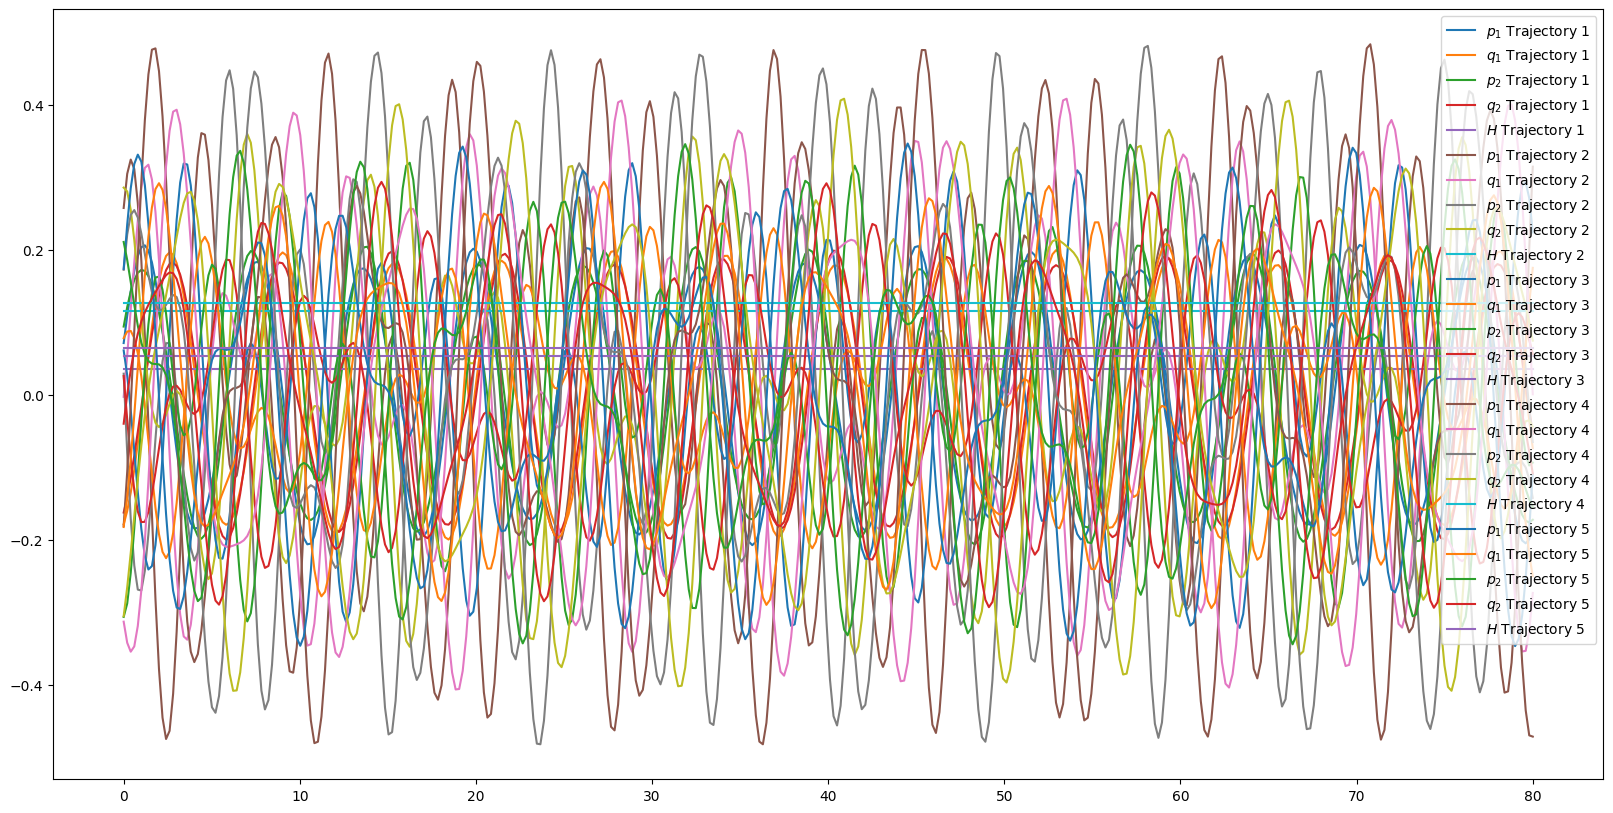

In [14]:
plt.figure(figsize=(20, 10))

for k, pq in enumerate(training_trajectories):

    p1, p2, q1, q2 = pq.T
    H = h_true(p1, p2, q1, q2)

    i, j = k // 2, k % 2
    plt.plot(t, p1, label=f"$p_1$ Trajectory {k + 1}")
    plt.plot(t, q1, label=f"$q_1$ Trajectory {k + 1}")
    plt.plot(t, p2, label=f"$p_2$ Trajectory {k + 1}")
    plt.plot(t, q2, label=f"$q_2$ Trajectory {k + 1}")
    plt.plot(t, H, label=f"$H$ Trajectory {k + 1}")
    plt.legend()


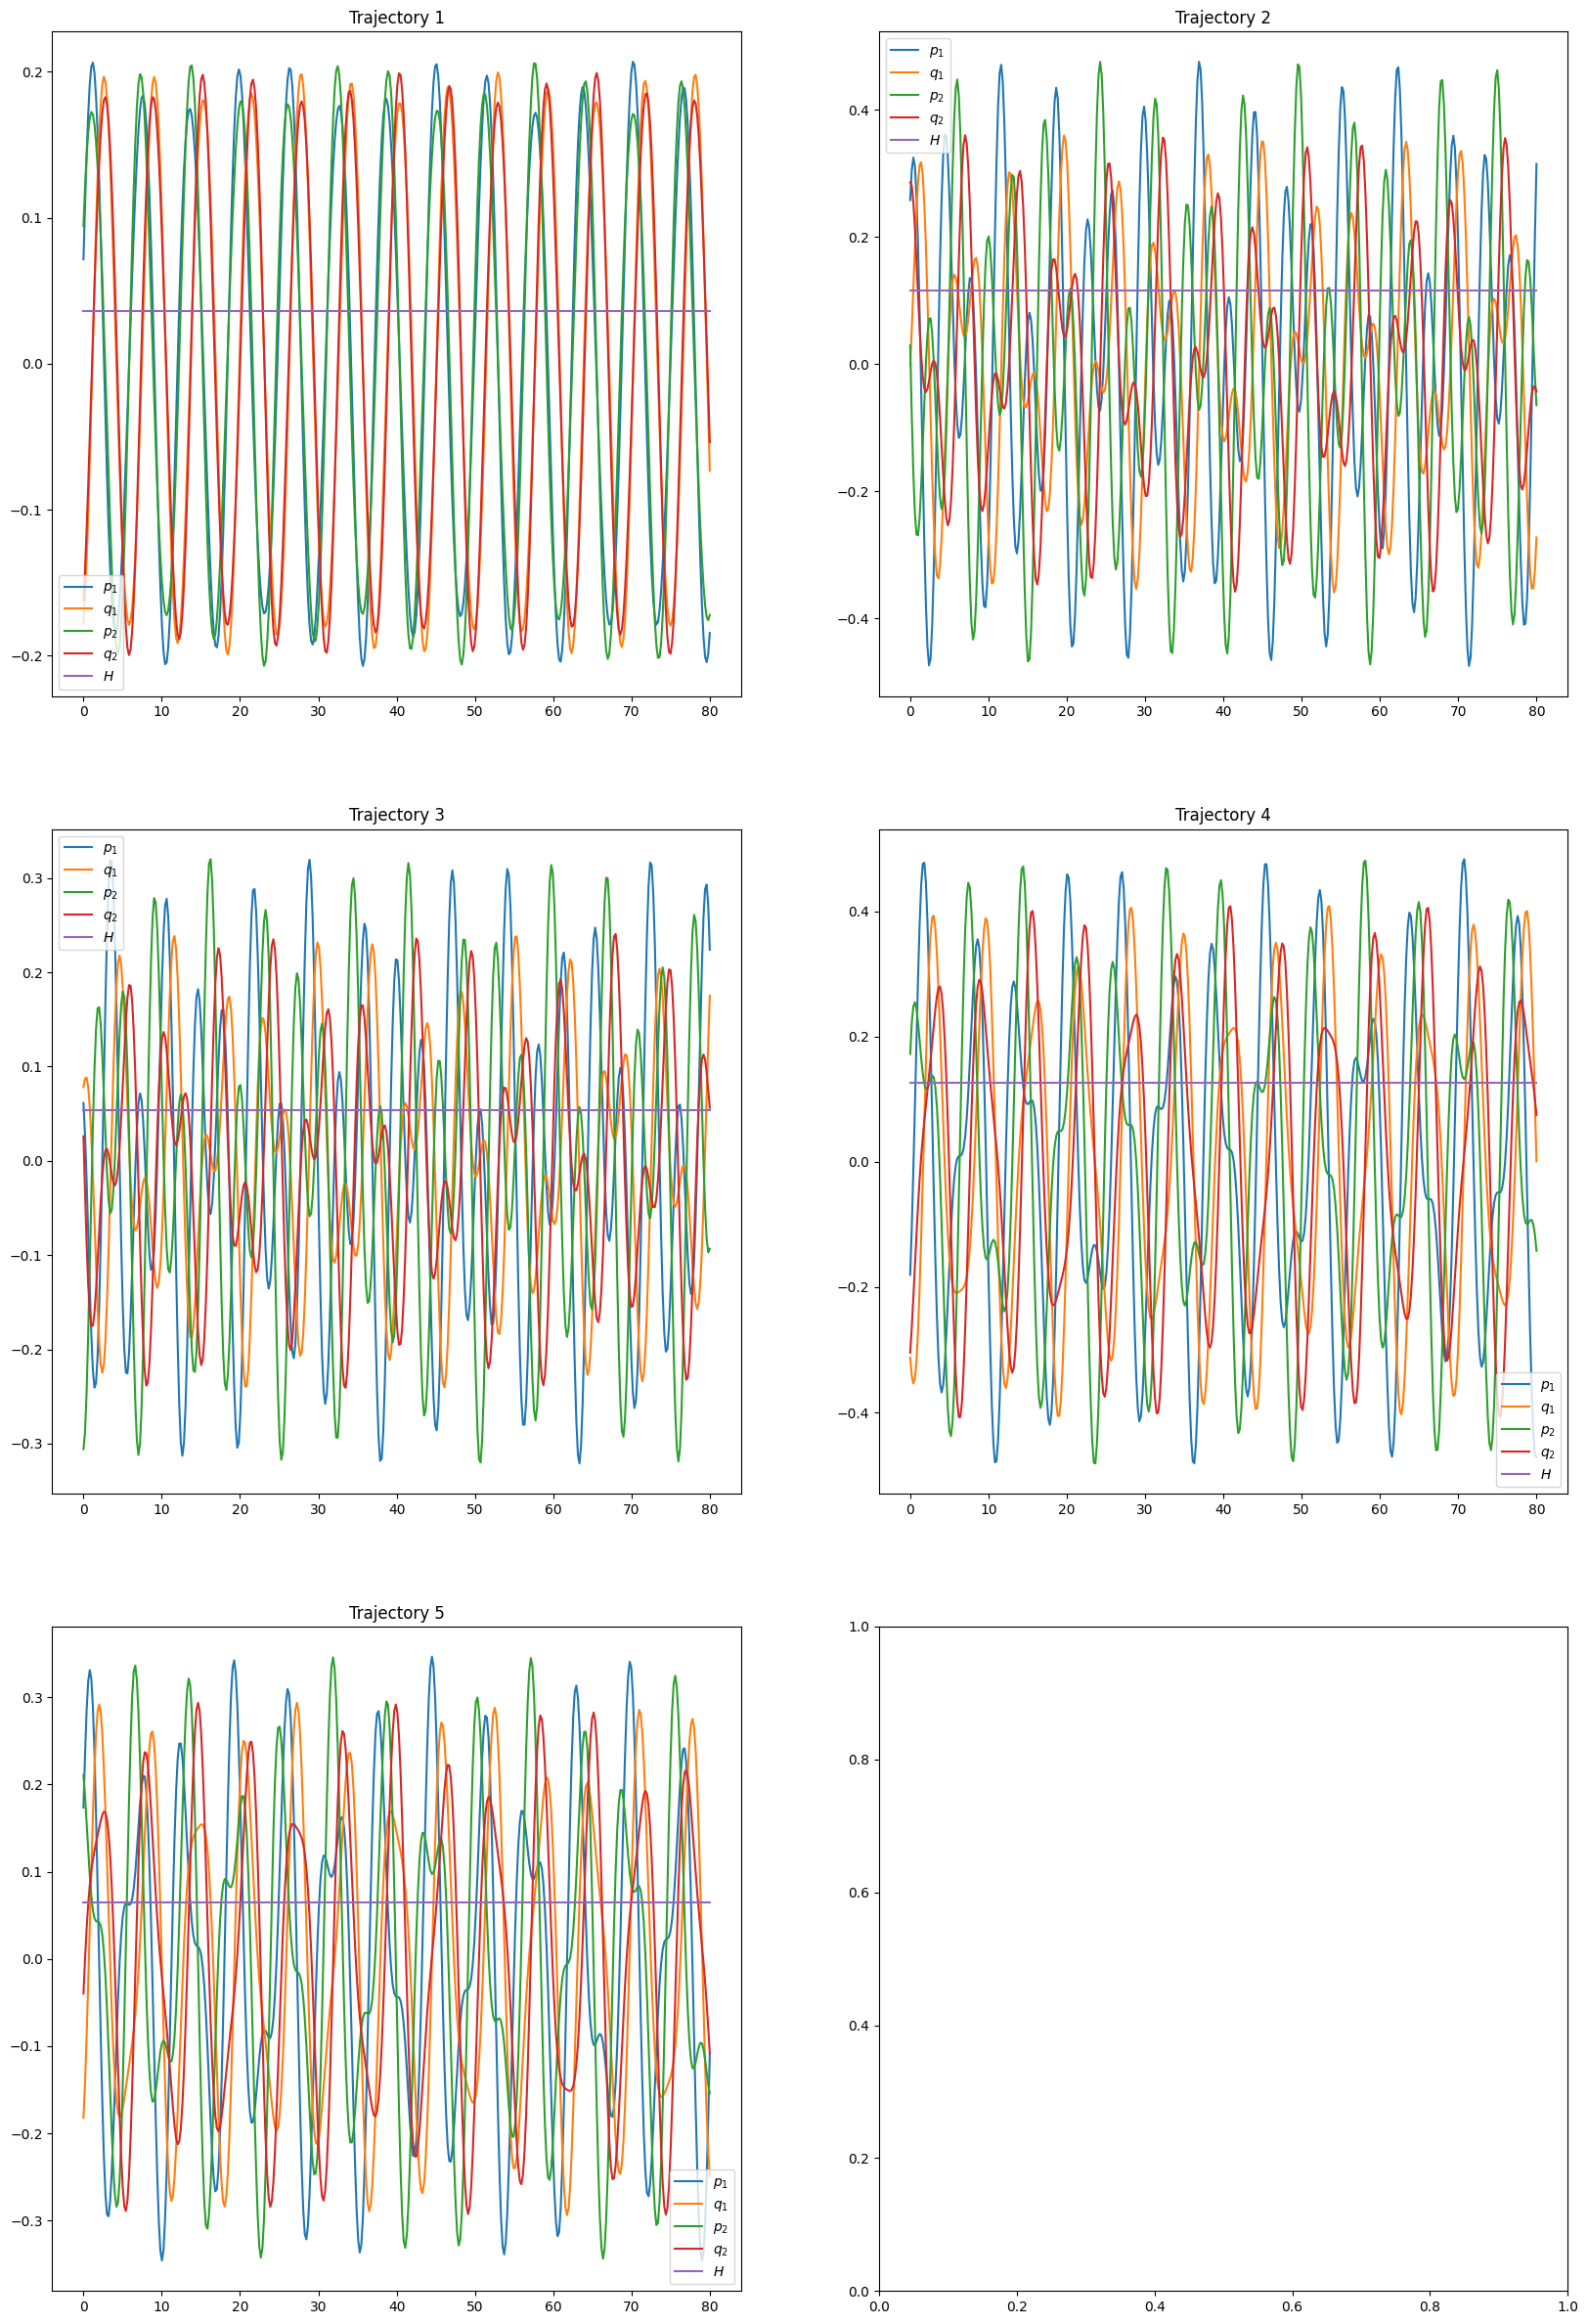

In [15]:
fig, axes = plt.subplots(np.ceil(N_TRAJICTORIES_TRAIN / 2).astype(int), 2, figsize=(20, 10 * np.ceil(N_TRAJICTORIES_TRAIN / 2).astype(int)))

for k, pq in enumerate(training_trajectories):

    p1, p2, q1, q2 = pq.T
    H = h_true(p1, p2, q1, q2)

    i, j = k // 2, k % 2

    axes_index = (i, j) if axes.ndim > 1 else (k, )

    axes[axes_index].plot(t, p1, label=f"$p_1$")
    axes[axes_index].plot(t, q1, label=f"$q_1$")
    axes[axes_index].plot(t, p2, label=f"$p_2$")
    axes[axes_index].plot(t, q2, label=f"$q_2$")
    axes[axes_index].plot(t, H, label=f"$H$")
    axes[axes_index].set_title(f"Trajectory {k + 1}")
    axes[axes_index].legend()

In [21]:
rng = np.random.default_rng(0)

all_trajectories_observed = []
all_trajectories_hidden = []
all_p0q0_observed = []
all_p0q0_hidden = []
all_H_observed = []
all_H_hidden = []

for p0q0, pq in zip(training_initial_conds, training_trajectories):
    p1, p2, q1, q2 = pq.T
    H = h_true(p1, p2, q1, q2)

    all_trajectories_observed.append(pq[:OBSERVATIONS_END, :])
    all_trajectories_hidden.append(pq[OBSERVATIONS_END:, :])
    all_p0q0_observed.append(np.tile(p0q0, (OBSERVATIONS_END, 1)))
    all_p0q0_hidden.append(np.tile(p0q0, (N - OBSERVATIONS_END, 1)))
    all_H_observed.append(H[:OBSERVATIONS_END, np.newaxis])
    all_H_hidden.append(H[OBSERVATIONS_END:, np.newaxis])


X_true = np.concatenate([
    np.concatenate(
        [np.tile(t[:OBSERVATIONS_END], N_TRAJICTORIES_TRAIN)[:, np.newaxis], 
        np.tile(t[OBSERVATIONS_END:], N_TRAJICTORIES_TRAIN)[:, np.newaxis]],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_p0q0_observed, axis=0), 
        np.concatenate(all_p0q0_hidden, axis=0)],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_trajectories_observed, axis=0), 
        np.concatenate(all_trajectories_hidden, axis=0)],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_H_observed, axis=0),
        np.concatenate(all_H_hidden, axis=0)],
        axis=0
    )],
    axis=1
)

M = np.ones_like(X_true).astype(bool)

for i in range(N_TRAJICTORIES_TRAIN):
    sparse_mask = rng.choice([False, True], p=[SPARSITY_FACTOR, 1 - SPARSITY_FACTOR], size=OBSERVATIONS_END)
    sparse_mask[-1] = True

    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 5] = sparse_mask
    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 6] = sparse_mask
    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 7] = sparse_mask
    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 8] = sparse_mask

M[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3:5] = False
M[:, 9] = False

X = np.full_like(X_true, fill_value=0)
X[M] = X_true[M]

In [22]:
hh_graph = ComputationalGraph(observables_order=["t", "p10", "p20", "q10", "q20", "p1", "p2", "q1", "q2", "H"])

hh_graph.add_observable("t")
hh_graph.add_observable("p10")
hh_graph.add_observable("p20")
hh_graph.add_observable("q10")
hh_graph.add_observable("q20")

hh_graph.add_aggregator(["t", "p10", "p20", "q10", "q20"], "tp0q0")

hh_graph.add_unknown_fn("tp0q0", "q1", alpha=P_KERNEL_NUGGET, kernel=P_KERNEL, kernel_parameters=P_KERNEL_PARAMS)
hh_graph.add_unknown_fn("tp0q0", "p1", alpha=Q_KERNEL_NUGGET, kernel=Q_KERNEL, kernel_parameters=Q_KERNEL_PARAMS)
hh_graph.add_unknown_fn("tp0q0", "q2", alpha=P_KERNEL_NUGGET, kernel=P_KERNEL, kernel_parameters=P_KERNEL_PARAMS)
hh_graph.add_unknown_fn("tp0q0", "p2", alpha=Q_KERNEL_NUGGET, kernel=Q_KERNEL, kernel_parameters=Q_KERNEL_PARAMS)

hh_graph.add_known_fn("p1", "p1_grad", derivative)
hh_graph.add_known_fn("p2", "p2_grad", derivative)
hh_graph.add_known_fn("q1", "q1_grad", derivative)
hh_graph.add_known_fn("q2", "q2_grad", derivative)

hh_graph.add_known_fn("p1_grad", "p1_dot", lambda p1_grad: p1_grad[:, 0])
hh_graph.add_known_fn("q1_grad", "q1_dot", lambda q1_grad: q1_grad[:, 0])
hh_graph.add_known_fn("p2_grad", "p2_dot", lambda p2_grad: p2_grad[:, 0])
hh_graph.add_known_fn("q2_grad", "q2_dot", lambda q2_grad: q2_grad[:, 0])

hh_graph.add_aggregator(["q1_dot", "q2_dot"], "q_dot")
hh_graph.add_aggregator(["p1_dot", "p2_dot"], "p_dot")
hh_graph.add_known_fn("p_dot", "-p_dot", lambda p_dot: -p_dot)

hh_graph.add_aggregator(["q_dot", "-p_dot"], "qp_dot")
hh_graph.add_aggregator(["p1", "p2", "q1", "q2"], "pq")

hh_graph.add_unknown_fn("pq", "H", linear_functional=jax.jacobian, observations="qp_dot", alpha=H_KERNEL_NUGGET, kernel=H_KERNEL, kernel_parameters=H_KERNEL_PARAMS)
hh_graph.add_known_fn("H", "grad_H", derivative)

hh_graph.add_aggregator(["p_dot", "grad_H"], "(p_dot, grad_H)")
def p_dot_constraint(p_dot_grad_H):
    p_dot, grad_H = p_dot_grad_H[:, :2], p_dot_grad_H[:, 2:]
    return p_dot + grad_H[:, 2:]

hh_graph.add_aggregator(["q_dot", "grad_H"], "(q_dot, grad_H)")
def q_dot_constraint(q_dot_grad_H):
    q_dot, grad_H = q_dot_grad_H[:, :2], q_dot_grad_H[:, 2:]
    return q_dot - grad_H[:, :2]

hh_graph.add_constraint("(p_dot, grad_H)", "W1", p_dot_constraint)
hh_graph.add_constraint("(q_dot, grad_H)", "W2", q_dot_constraint)

In [23]:
p_2s, q_2s, H_2s = two_steps_pqH(X, M, OBSERVATIONS_END, num_trajectories=N_TRAJICTORIES_TRAIN, use_T_in_second_step=True)
X_init = initialize_X_for_one_step(X, M, p_2s, q_2s, H_2s, dims=2)
unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier = initalize_one_step_loss_multipliers(hh_graph, X_init, M)

## Two-Steps Seen Trajectories Extrapolation

In [24]:
two_steps_mse_p = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7])
two_steps_mse_q = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9])

two_steps_re_p = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7]) * 100
two_steps_re_q = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9]) * 100

pd.DataFrame({"P": [two_steps_mse_p, two_steps_re_p], "Q": [two_steps_mse_q, two_steps_re_q]}, index=["MSE", "Relative"])

,P,Q
MSE,0.00000264929626902,0.00000131850621010
Relative,1.07326668531219593,0.64294841493181942


## Two-Steps Unseen Trajectories Extrapolation

In [25]:
two_steps_p_mse_errors = []
two_steps_p_re_errors = []
two_steps_q_mse_errors = []
two_steps_q_re_errors = []

t = np.linspace(0, T_MAX, N)

for init_cond, pq_true in tqdm(zip(test_initial_conds, test_trajectories)):

    pq_pred = integerate_H_est(H_2s, init_cond, t, dims=2)
    two_steps_p_mse_errors.append(mse(pq_true[:, 0:2], pq_pred[:, 0:2]))
    two_steps_p_re_errors.append(relative_error(pq_true[:, 0:2], pq_pred[:, 0:2]) * 100)
    two_steps_q_mse_errors.append(mse(pq_true[:, 2:4], pq_pred[:, 2:4]))
    two_steps_q_re_errors.append(relative_error(pq_true[:, 2:4], pq_pred[:, 2:4]) * 100)

pd.DataFrame({
    "P": [
        np.mean(two_steps_p_mse_errors), np.std(two_steps_p_mse_errors), 
        np.mean(two_steps_p_re_errors), np.std(two_steps_p_re_errors)
    ], 
    "Q": [
        np.mean(two_steps_q_mse_errors), np.std(two_steps_q_mse_errors),
        np.mean(two_steps_q_re_errors), np.std(two_steps_q_re_errors)
    ]
}, index=["MSE avg.", "MSE std.", "Relative avg.", "Relative std."])

50it [00:23,  2.16it/s]


,P,Q
MSE avg.,0.00157988051626146,0.00053297276766724
MSE std.,0.00099206929497033,0.00033228620105220
Relative avg.,16.82448687711563551,13.82476002797124082
Relative std.,6.55455228497593900,7.58872774760375801


## Two-Steps Recovered Hamiltonian Coeffcients Error

In [26]:
estimated_coefs = get_seprable_H_coef(X_init, OBSERVATIONS_END, N_TRAJICTORIES_TRAIN)
relative_error(TRUE_COEFS, estimated_coefs)

['1', 'p1', 'p2', 'p1^2', 'p1 p2', 'p2^2', 'p1^3', 'p1^2 p2', 'p1 p2^2', 'p2^3', '1', 'q1', 'q2', 'q1^2', 'q1 q2', 'q2^2', 'q1^3', 'q1^2 q2', 'q1 q2^2', 'q2^3']
[ 1.79887861e-02 -1.89183709e-05 -2.05919591e-05  3.94456488e-04
  3.13577077e-04  4.32172428e-04  2.27813714e-04  2.09051396e-04
  2.19895543e-04  2.60866285e-04  1.79887861e-02  3.79354584e-05
 -4.96895897e-05  1.58288302e-04  3.29373009e-04  4.43761029e-04
  1.64541588e-04  1.43723361e-04  1.29143968e-04  1.20384930e-04]


np.float64(0.9997660653044236)

In [27]:
hh_graph.set_loss_multipliers(unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier)

In [28]:
Z = hh_graph.complete(
    X_init[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, :], 
    M[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, :], 
    OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, optimizer="l-bfgs-b", learn_parameters=False, n_rounds=1)

 Loss: 5.2709:   0%|          | 74/1000000 [00:20<75:55:46,  3.66it/s] 


In [29]:
def get_hamiltonian_from(graph: ComputationalGraph, Z):
    """Retunr a callable for the learned hamiltonina from CGC."""
    H_fn = graph._unknown_functions["H"]
    return lambda pq: H_fn._f(pq, H_fn.parameter(Z), H_fn.observation(Z))


In [30]:
H_est = one_step_hamiltonian(Z, OBSERVATIONS_END, num_trajectories=N_TRAJICTORIES_TRAIN)
#H_est = get_hamiltonian_from(hh_graph, Z)
H_grad = jax.jit(jax.grad(H_est))
_, pq_size = Z.shape

T = X[:, 0]
Z_new = np.asarray(X).copy()
extra_steps = N - OBSERVATIONS_END 
for i in range(N_TRAJICTORIES_TRAIN):

    init_point = Z[OBSERVATIONS_END * (i + 1)  - 1, 5:pq_size - 1]

    def kernel_ode(pq, t):
        dims = (pq_size - 6) // 2
        grad_val = H_grad(pq)
        dpH = grad_val[0: dims]
        dqH = grad_val[dims: 2 * dims]

        return np.concatenate([-dqH, dpH])
        
    extrapolation_time_start = OBSERVATIONS_END * N_TRAJICTORIES_TRAIN
    extrapolation_time = np.concatenate((
        np.reshape(T[OBSERVATIONS_END * (i + 1) - 1], (1,)), 
        T[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1)]
    ), axis=0)
    
    pq_2s = odeint(kernel_ode, init_point, extrapolation_time)

    Z_new[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1), 5:pq_size - 1] = pq_2s[1:, :]


Z_new[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 5:pq_size - 1] = Z[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 5:pq_size - 1]
Z_new[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, -1] = Z[:, -1]
Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, pq_size - 1] = jax.jit(jax.vmap(H_est))(Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:pq_size - 1])

## CGC Seen Trajectories Extrapolation

In [31]:
one_step_mse_p = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7])
one_step_mse_q = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9])

one_step_re_p = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 5:7]) * 100
one_step_re_q = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 7:9]) * 100

pd.DataFrame({"P": [one_step_mse_p, one_step_re_p], "Q": [one_step_mse_q, one_step_re_q]}, index=["MSE", "Relative"]) 

,P,Q
MSE,0.00000211810283827,0.00000085754450886
Relative,1.03715476150406305,0.60735606745261361


## CGC Unseen Trajectories Extrapolation

In [32]:
one_step_p_mse_errors = []
one_step_p_re_errors = []
one_step_q_mse_errors = []
one_step_q_re_errors = []

t = np.linspace(0, T_MAX, N)

for init_cond, pq_true in tqdm(zip(test_initial_conds, test_trajectories)):

    pq_pred = integerate_H_est(H_est, init_cond, t, dims=2)
    one_step_p_mse_errors.append(mse(pq_true[:, 0], pq_pred[:, 0]))
    one_step_p_re_errors.append(relative_error(pq_true[:, 0], pq_pred[:, 0]) * 100)
    one_step_q_mse_errors.append(mse(pq_true[:, 1], pq_pred[:, 1]))
    one_step_q_re_errors.append(relative_error(pq_true[:, 1], pq_pred[:, 1]) * 100)

pd.DataFrame({
    "P": [
        np.mean(one_step_p_mse_errors), np.std(one_step_p_mse_errors),
        np.mean(one_step_p_re_errors), np.std(one_step_p_re_errors)
    ], 
    "Q": [
        np.mean(one_step_q_mse_errors), np.std(one_step_q_mse_errors),
        np.mean(one_step_q_re_errors), np.std(one_step_q_re_errors)
    ]
}, index=["MSE avg.", "MSE std.", "Relative avg.", "Relative std."])

50it [00:23,  2.17it/s]


,P,Q
MSE avg.,0.00148649764756782,0.00148599512491444
MSE std.,0.00093639546399555,0.00093646275316285
Relative avg.,14.09354743655542919,14.13141821694062905
Relative std.,5.45375793920258278,5.49537542060896023


In [33]:
estimated_coefs = get_seprable_H_coef(Z, OBSERVATIONS_END, N_TRAJICTORIES_TRAIN)

print(relative_error(TRUE_COEFS, estimated_coefs))

['1', 'p1', 'p2', 'p1^2', 'p1 p2', 'p2^2', 'p1^3', 'p1^2 p2', 'p1 p2^2', 'p2^3', '1', 'q1', 'q2', 'q1^2', 'q1 q2', 'q2^2', 'q1^3', 'q1^2 q2', 'q1 q2^2', 'q2^3']
[ 1.79947318e-02 -6.30862361e-06 -7.71765685e-06  3.53993135e-04
  3.07204635e-04  3.65123692e-04  5.15186005e-05  6.44384721e-05
  8.19224026e-05  1.05288049e-04  1.79947318e-02  8.20378599e-06
 -1.14897670e-05  2.96491200e-04  3.20454482e-04  3.17364565e-04
  4.60274595e-05  4.03531974e-05  3.52426211e-05  3.06282312e-05]
0.9998235455264077
